# Model Training

In [9]:
!pip install catboost 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

import warnings

In [10]:
from catboost import CatBoostRegressor

In [2]:
df=pd.read_csv('stud.csv')

In [3]:
df.head(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['Average']=df['total_score']/3

In [5]:
df.shape

(1000, 10)

Preparing X and Y feature

In [14]:
X=df.drop(columns=['math_score'],axis=1)

In [15]:
X.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score,total_score,Average
0,female,group B,bachelor's degree,standard,none,72,74,218,72.666667
1,female,group C,some college,standard,completed,90,88,247,82.333333


In [16]:
y=df['math_score']

In [17]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

### Create a Column Transformer with 3 Types of transformers.

In [18]:
numerical_features=X.select_dtypes(exclude="object").columns
categorical_features=X.select_dtypes(include="object").columns

from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_transformer=StandardScaler()
OH_transformer=OneHotEncoder()

preproccesor=ColumnTransformer(
[
    ("OneHotEncoder",OH_transformer,categorical_features),
    ("StandardScaler",numerical_transformer,numerical_features),
])

In [19]:
X=preproccesor.fit_transform(X)

In [20]:
X.shape

(1000, 21)

Splitting the data into train and test

In [21]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [22]:
print(X_train.shape)
print(X_test.shape)


(700, 21)
(300, 21)


Creating a Evaluate function

In [23]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mean_squared_error(true,predicted))
    r2=r2_score(true,predicted)
    return mae,rmse,r2

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor(),
    "Catboost Regressor": CatBoostRegressor(verbose=False),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor()
}

model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)    # Train Model
    
    #Make predictions
    
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000


Ridge Regression
Model performance for Training set
- Root Mean Squared Error: 0.3882
- Mean Absolute Error: 0.3106
- R2 Score: 0.9993
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4109
- Mean Absolute Error: 0.3274
- R2 Score: 0.9993


Lasso Regression
Model performance for Training set
- Root Mean Squared Error: 4.6538
- Mean Absolute Error: 3.6848
- R2 Score: 0.9018
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 4.9626
- Mean Absolute Error: 3.9339
- R2 Score: 0.9010


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 4.2054
- Mean Absolute Error: 3.3160
- R2 Score: 0.9198
-

# Result

In [26]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_Score']).sort_values(by=['R2_Score'],ascending=False)

,Model Name,R2_Score
0,Linear Regression,1.000000
1,Ridge Regression,0.999321
5,Catboost Regressor,0.965072
6,Random Forest Regressor,0.950303
4,XGBoost Regressor,0.949055
7,AdaBoost Regressor,0.915894
8,Decision Tree Regressor,0.913013
2,Lasso Regression,0.901020
3,K-Neighbors Regressor,0.889137


# Linear Regression

In [35]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model. fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 100.00


# Plot y_pred and y_test

Text(0, 0.5, 'Predicted')

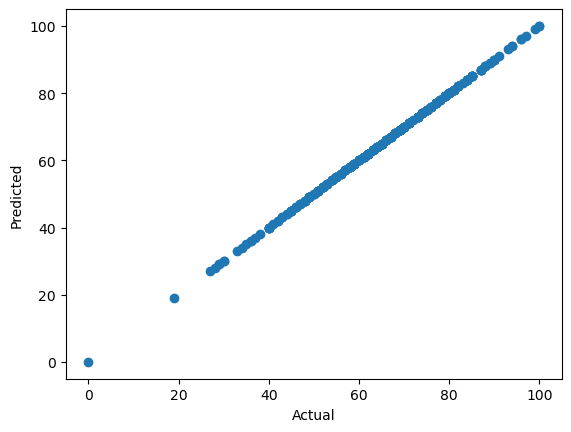

In [36]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')

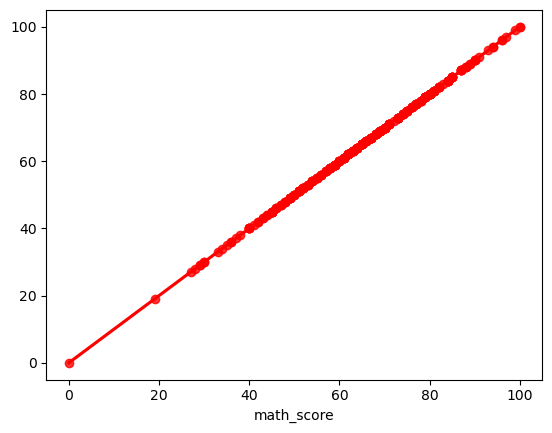

In [37]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [38]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,91.0,-2.273737e-13
737,53,53.0,2.131628e-14
740,80,80.0,-2.842171e-14
660,74,74.0,-8.526513e-14
411,84,84.0,-1.421085e-13
...,...,...,...
468,77,77.0,-1.989520e-13
935,70,70.0,9.947598e-14
428,65,65.0,1.563194e-13
7,40,40.0,3.623768e-13
